## 1. Setup

In [1]:
import torch
import torch.nn as nn
import random
import numpy as np

print(torch.__version__)
print(torch.cuda.is_available())

# fixed seed -> same results every run
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

2.11.0+cpu
False
Using device: cpu


## 2. Download dataset

In [2]:
import os
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


## 3. Explore the raw folders (original structure)

In [3]:
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        n = len(os.listdir(path + f"/chest_xray/{split}/{cls}"))
        print(split, cls, n)

train NORMAL 1341
train PNEUMONIA 3875
val NORMAL 8
val PNEUMONIA 8
test NORMAL 234
test PNEUMONIA 390


Train: 1,341 NORMAL + 3,875 PNEUMONIA = 5,216
Original val: 8 + 8 = 16  →  **too small, not used from here on**
Test: 234 NORMAL + 390 PNEUMONIA = 624  →  **locked until final evaluation**

## 4. Transforms

In [4]:
from torchvision import datasets, transforms

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# training: with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# validation and test: NO augmentation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

## 5. Fix the validation set — proper 90/10 stratified split

The 5,216 training images are loaded **twice**, with two different transforms. We then split the *index numbers* (not the images themselves) 90/10, keeping the NORMAL:PNEUMONIA ratio the same in both halves (`stratify`). Finally we use `Subset` to pull the right indices from the correctly-transformed copy. The test set is loaded separately and is never touched here.

In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Load the train folder twice: one copy augmented, one copy not
full_train_aug  = datasets.ImageFolder(path + "/chest_xray/train", transform=train_transform)
full_train_eval = datasets.ImageFolder(path + "/chest_xray/train", transform=eval_transform)

# The locked test set
test_dataset = datasets.ImageFolder(path + "/chest_xray/test", transform=eval_transform)

targets = full_train_aug.targets   # 0 = NORMAL, 1 = PNEUMONIA, one label per image

train_idx, val_idx = train_test_split(
    range(len(targets)),
    test_size=0.10,
    stratify=targets,
    random_state=42
)

new_train_dataset = Subset(full_train_aug,  train_idx)   # augmented copy -> train
new_val_dataset   = Subset(full_train_eval, val_idx)     # clean copy -> validation

print("New train:", len(new_train_dataset))
print("New val:  ", len(new_val_dataset))
print("Test (locked):", len(test_dataset))

New train: 4694
New val:   522
Test (locked): 624


In [6]:
from collections import Counter

train_targets = [targets[i] for i in train_idx]
val_targets   = [targets[i] for i in val_idx]

print("New train class counts:", Counter(train_targets))
print("New val class counts:  ", Counter(val_targets))
print("class_to_idx:", full_train_aug.class_to_idx)

New train class counts: Counter({1: 3487, 0: 1207})
New val class counts:   Counter({1: 388, 0: 134})
class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}


## 6. DataLoaders

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(new_train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(new_val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,      batch_size=32, shuffle=False)

print(len(train_loader), len(val_loader), len(test_loader))

147 17 20


## 7. Quick look at the data

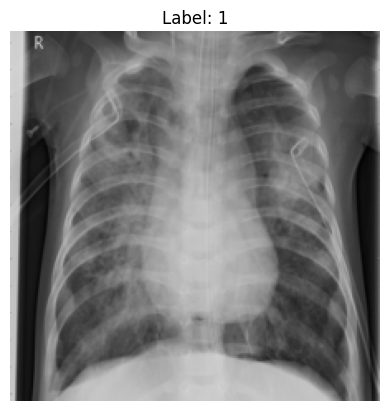

In [8]:
import matplotlib.pyplot as plt

image, label = new_train_dataset[0]
image_show = image.clone()
for t, m, s in zip(image_show, mean, std):
    t.mul_(s).add_(m)

plt.imshow(image_show.permute(1, 2, 0).clamp(0, 1))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

## 8. CNN model

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=10,
                               kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20,
                               kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_features=250880, out_features=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

## 9. Class imbalance — weights recalculated from the NEW train split

Old weights (1.9448 / 0.6730) came from the *old* 5,216-image train set. Now that 10% of it moved to validation, the new train set has slightly different counts, so we recompute.

In [10]:
normal_count    = Counter(train_targets)[0]
pneumonia_count = Counter(train_targets)[1]
total = normal_count + pneumonia_count
num_classes = 2

normal_weight    = total / (num_classes * normal_count)
pneumonia_weight = total / (num_classes * pneumonia_count)

class_weights = torch.tensor([normal_weight, pneumonia_weight]).to(device)
print("Normal weight:", normal_weight)
print("Pneumonia weight:", pneumonia_weight)
print(class_weights)

Normal weight: 1.944490472245236
Pneumonia weight: 0.6730714080871809
tensor([1.9445, 0.6731])


## 10. Reusable train & evaluate functions

Both experiments (plain CNN, weighted CNN) need the same training loop and the same evaluation logic. Writing it once avoids copy-pasting the loop twice and getting them out of sync.

In [11]:
def train_model(model, loader, criterion, optimizer, epochs=3):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            if batch_idx % 20 == 0:
                print(f"Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}")
    return model

In [12]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = torch.argmax(model(images), dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    return torch.cat(all_labels), torch.cat(all_preds)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def metrics_report(y_true, y_pred, title=""):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"--- {title} ---")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print(cm)

    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.show()

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}

## 11. Experiment A — Custom CNN (no class weights)

In [14]:
set_seed(42)
cnn_plain = CNN().to(device)
criterion_plain = nn.CrossEntropyLoss()
optimizer_plain = torch.optim.Adam(cnn_plain.parameters(), lr=0.001)

cnn_plain = train_model(cnn_plain, train_loader, criterion_plain, optimizer_plain, epochs=3)

Epoch: 0, Batch: 0, Loss: 0.6795
Epoch: 0, Batch: 20, Loss: 0.4184
Epoch: 0, Batch: 40, Loss: 0.1565
Epoch: 0, Batch: 60, Loss: 0.3435
Epoch: 0, Batch: 80, Loss: 0.0986
Epoch: 0, Batch: 100, Loss: 0.0731
Epoch: 0, Batch: 120, Loss: 0.0375
Epoch: 0, Batch: 140, Loss: 0.0899
Epoch: 1, Batch: 0, Loss: 0.0690
Epoch: 1, Batch: 20, Loss: 0.1649
Epoch: 1, Batch: 40, Loss: 0.1620
Epoch: 1, Batch: 60, Loss: 0.0705
Epoch: 1, Batch: 80, Loss: 0.0564
Epoch: 1, Batch: 100, Loss: 0.1395
Epoch: 1, Batch: 120, Loss: 0.0542
Epoch: 1, Batch: 140, Loss: 0.0847
Epoch: 2, Batch: 0, Loss: 0.0922
Epoch: 2, Batch: 20, Loss: 0.1365
Epoch: 2, Batch: 40, Loss: 0.0303
Epoch: 2, Batch: 60, Loss: 0.0598
Epoch: 2, Batch: 80, Loss: 0.0129
Epoch: 2, Batch: 100, Loss: 0.2319
Epoch: 2, Batch: 120, Loss: 0.0838
Epoch: 2, Batch: 140, Loss: 0.0600


--- Custom CNN — New Validation Set ---
Accuracy : 0.9731800766283525
Precision: 0.9819587628865979
Recall   : 0.9819587628865979
F1-score : 0.9819587628865979
[[127   7]
 [  7 381]]


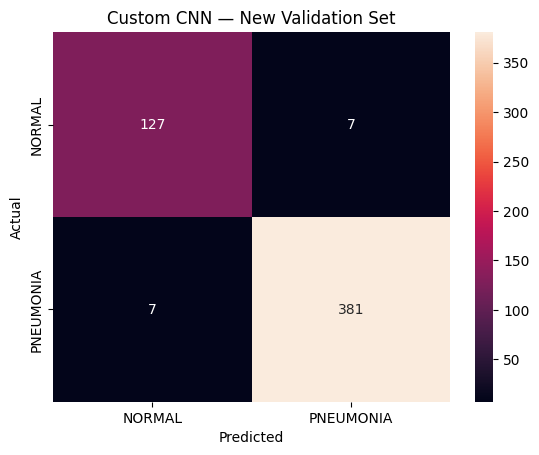

In [15]:
y_true, y_pred = evaluate(cnn_plain, val_loader)
results_plain_cnn = metrics_report(y_true, y_pred, title="Custom CNN — New Validation Set")

## 12. Experiment B — Weighted CNN (class weights applied)

In [16]:
set_seed(42)
cnn_weighted = CNN().to(device)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)
optimizer_weighted = torch.optim.Adam(cnn_weighted.parameters(), lr=0.001)

cnn_weighted = train_model(cnn_weighted, train_loader, criterion_weighted, optimizer_weighted, epochs=3)

Epoch: 0, Batch: 0, Loss: 0.6857
Epoch: 0, Batch: 20, Loss: 0.4905
Epoch: 0, Batch: 40, Loss: 0.2484
Epoch: 0, Batch: 60, Loss: 0.1986
Epoch: 0, Batch: 80, Loss: 0.0637
Epoch: 0, Batch: 100, Loss: 0.1497
Epoch: 0, Batch: 120, Loss: 0.0282
Epoch: 0, Batch: 140, Loss: 0.1062
Epoch: 1, Batch: 0, Loss: 0.0906
Epoch: 1, Batch: 20, Loss: 0.1310
Epoch: 1, Batch: 40, Loss: 0.3739
Epoch: 1, Batch: 60, Loss: 0.1143
Epoch: 1, Batch: 80, Loss: 0.0458
Epoch: 1, Batch: 100, Loss: 0.1263
Epoch: 1, Batch: 120, Loss: 0.0460
Epoch: 1, Batch: 140, Loss: 0.0862
Epoch: 2, Batch: 0, Loss: 0.0682
Epoch: 2, Batch: 20, Loss: 0.1861
Epoch: 2, Batch: 40, Loss: 0.0610
Epoch: 2, Batch: 60, Loss: 0.0663
Epoch: 2, Batch: 80, Loss: 0.0157
Epoch: 2, Batch: 100, Loss: 0.2322
Epoch: 2, Batch: 120, Loss: 0.0505
Epoch: 2, Batch: 140, Loss: 0.0750


--- Weighted CNN — New Validation Set ---
Accuracy : 0.9655172413793104
Precision: 0.9792746113989638
Recall   : 0.9742268041237113
F1-score : 0.9767441860465116
[[126   8]
 [ 10 378]]


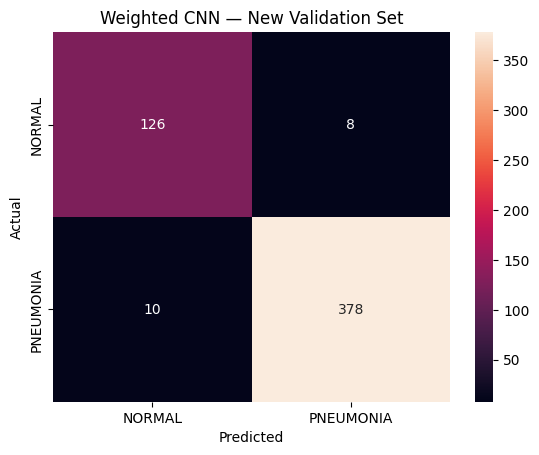

In [17]:
y_true, y_pred = evaluate(cnn_weighted, val_loader)
results_weighted_cnn = metrics_report(y_true, y_pred, title="Weighted CNN — New Validation Set")

In [21]:
torch.save(cnn_plain.state_dict(), "cnn_plain.pth")
torch.save(cnn_weighted.state_dict(), "cnn_weighted.pth")

--- Custom CNN — Locked Test Set ---
Accuracy : 0.7275641025641025
Precision: 0.6985559566787004
Recall   : 0.9923076923076923
F1-score : 0.8199152542372882
[[ 67 167]
 [  3 387]]


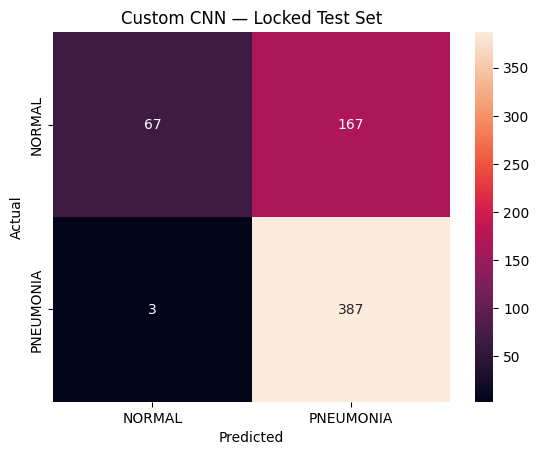

{'accuracy': 0.7275641025641025,
 'precision': 0.6985559566787004,
 'recall': 0.9923076923076923,
 'f1': 0.8199152542372882,
 'confusion_matrix': array([[ 67, 167],
        [  3, 387]])}

In [22]:
#Final evaluvation on locked test set
y_true, y_pred = evaluate(cnn_plain, test_loader)
metrics_report(y_true, y_pred, title="Custom CNN — Locked Test Set")